# DCG Multiview Refactor - Colab T4 Training Notebook

This notebook is prepared for Google Colab with a T4 GPU.

## What it does
1. Verifies GPU and CUDA.
2. Clones your repository (or uses Google Drive copy).
3. Installs required Python packages.
4. Checks shared dataset files under `datasets/`.
5. Runs training with configurable dataset and epochs.

Set Runtime -> Change runtime type -> GPU before running.

In [1]:
import torch
import subprocess

print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
subprocess.run(['nvidia-smi'])

Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


CompletedProcess(args=['nvidia-smi'], returncode=0)

In [ ]:
# Install gdown if needed
%pip install -q gdown

In [42]:
import os
import gdown
import shutil
import zipfile

BASE_DIR = "/content"

# Download the GitHub project
PROJECT_ROOT = os.path.join(BASE_DIR, "Diffusion-based-approaches")
ZIP_PATH = os.path.join(BASE_DIR, "repo.zip")
EXTRACTED_FOLDER = os.path.join(BASE_DIR, "Diffusion-based-approaches-for-IMVC-main")
DCG_SRC = os.path.join(EXTRACTED_FOLDER, "DCG (NEW)")
DCG_DIR = os.path.join(PROJECT_ROOT, "DCG (NEW)")

os.makedirs(PROJECT_ROOT, exist_ok=True)

# Download ZIP from GitHub
subprocess.run([
    "wget", "-q", "-O", ZIP_PATH,
    "https://github.com/EddarirOmar/Diffusion-based-approaches-for-IMVC/archive/refs/heads/main.zip"
], check=True)

# Extract ZIP
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(BASE_DIR)

# Remove old DCG folder if exists
shutil.rmtree(DCG_DIR, ignore_errors=True)

# Move DCG folder to project root
shutil.move(DCG_SRC, PROJECT_ROOT)

print("Project downloaded to:", PROJECT_ROOT)
print("DCG path:", DCG_DIR)

Project downloaded to: /content/Diffusion-based-approaches (1)
DCG path: /content/Diffusion-based-approaches (1)/DCG (NEW)


In [50]:
# Download datasets
DATASETS_DIR = os.path.join(PROJECT_ROOT, "datasets")
os.makedirs(DATASETS_DIR, exist_ok=True)

# Dataset name → (Google Drive link, desired filename)
DATASET_FILES = {
    "Synthetic3d": ("https://drive.google.com/file/d/1sCgWYojsHjLqgEkijiD5XfreCIYw3APP/view?usp=sharing", "Synthetic3d.mat"),
    "Scene-15": ("https://drive.google.com/file/d/1ENVvuQPFNceR6zhS-c53Qg4qCoFi6sFQ/view?usp=sharing", "Scene-15.mat"),
    "NoisyMNIST": ("https://drive.google.com/file/d/1jLgApO9_RvoIb96nzIgiq2nv8T1WjCbi/view?usp=sharing", "NoisyMNIST.mat"),
    "LandUse-21": ("https://drive.google.com/file/d/19J6kxTYAvRHuCBrA7suPgc0Oe--C38e2/view?usp=sharing", "LandUse-21.mat"),
    "Handwritten": ("https://drive.google.com/file/d/17OpkAo5_TTIjmE4FfB00WPXMkZlVSpb9/view?usp=sharing", "Handwritten.mat"),
    "CUB": ("https://drive.google.com/file/d/1T1ndPETHyenoBGFhVAQZbJUL725XK9G0/view?usp=sharing", "CUB.mat"),
}

def download_datasets(dataset_files, dest_dir=DATASETS_DIR):
    os.makedirs(dest_dir, exist_ok=True)

    for name, (link, filename) in dataset_files.items():
        print(f"\nDownloading {name} ...")
        output_path = os.path.join(dest_dir, filename)

        # Extract file ID from Google Drive link
        file_id = link.split("/d/")[1].split("/")[0]
        gdown.download(f"https://drive.google.com/uc?id={file_id}", output_path, quiet=False)
        print(f"{name} ready at {output_path}")

# Run the download
download_datasets(DATASET_FILES)
print("\nAll datasets ready in:", DATASETS_DIR)

Downloading...
From (original): https://drive.google.com/uc?id=1sCgWYojsHjLqgEkijiD5XfreCIYw3APP
From (redirected): https://drive.google.com/uc?id=1sCgWYojsHjLqgEkijiD5XfreCIYw3APP&confirm=t&uuid=28567b5a-9395-4055-82d5-2a95b0bf9012
To: /content/Diffusion-based-approaches/datasets/Synthetic3d.mat
100%|██████████| 53.8k/53.8k [00:00<00:00, 33.7MB/s]


Synthetic3d ready at /content/Diffusion-based-approaches/datasets/Synthetic3d.mat



Downloading...
From (original): https://drive.google.com/uc?id=1ENVvuQPFNceR6zhS-c53Qg4qCoFi6sFQ
From (redirected): https://drive.google.com/uc?id=1ENVvuQPFNceR6zhS-c53Qg4qCoFi6sFQ&confirm=t&uuid=ef066aff-90e1-4de9-baef-e8dcc61cd38f
To: /content/Diffusion-based-approaches/datasets/Scene-15.mat
100%|██████████| 3.38M/3.38M [00:00<00:00, 197MB/s]


Scene-15 ready at /content/Diffusion-based-approaches/datasets/Scene-15.mat



Downloading...
From (original): https://drive.google.com/uc?id=1jLgApO9_RvoIb96nzIgiq2nv8T1WjCbi
From (redirected): https://drive.google.com/uc?id=1jLgApO9_RvoIb96nzIgiq2nv8T1WjCbi&confirm=t&uuid=bfd67726-fee5-4f9d-a709-8fdbcbe6e550
To: /content/Diffusion-based-approaches/datasets/NoisyMNIST.mat
100%|██████████| 480M/480M [00:04<00:00, 96.4MB/s]


...

LandUse-21 ready at /content/Diffusion-based-approaches/datasets/LandUse-21.mat



Downloading...
From (original): https://drive.google.com/uc?id=17OpkAo5_TTIjmE4FfB00WPXMkZlVSpb9
From (redirected): https://drive.google.com/uc?id=17OpkAo5_TTIjmE4FfB00WPXMkZlVSpb9&confirm=t&uuid=3fadf750-3818-48a4-b0e9-a1b293beb0e6
To: /content/Diffusion-based-approaches/datasets/Handwritten.mat
100%|██████████| 3.48M/3.48M [00:00<00:00, 168MB/s]


Handwritten ready at /content/Diffusion-based-approaches/datasets/Handwritten.mat



Downloading...
From (original): https://drive.google.com/uc?id=1T1ndPETHyenoBGFhVAQZbJUL725XK9G0
From (redirected): https://drive.google.com/uc?id=1T1ndPETHyenoBGFhVAQZbJUL725XK9G0&confirm=t&uuid=d83b877e-b226-490e-9969-76c5dbedbea0
To: /content/Diffusion-based-approaches/datasets/CUB.mat
100%|██████████| 3.18M/3.18M [00:00<00:00, 240MB/s]

CUB ready at /content/Diffusion-based-approaches/datasets/CUB.mat

All datasets ready in: /content/Diffusion-based-approaches/datasets


In [4]:
# Install required dependencies for this project
%pip install -q numpy scipy scikit-learn munkres

In [53]:
# Quick dataset presence check (shared datasets folder)
import os

data_dir = DATASETS_DIR
required = [
    'Handwritten.mat',
    'CUB.mat',
]


print('Data dir:', data_dir)
for f in required:
    p = os.path.join(data_dir, f)
    print(f, '->', 'FOUND' if os.path.exists(p) else 'MISSING')

Data dir: /content/Diffusion-based-approaches/datasets
Handwritten.mat -> FOUND
CUB.mat -> FOUND


In [12]:
# Optional quick sanity check
%cd {DCG_DIR}
!python smoke_test.py --dataset synthetic3d

/content/Diffusion-based-approaches/DCG (NEW)
shuffle
Epoch: 0/2 ==> loss = 6.3767 | rec=2.2702 df=1.9083 ce=2.0366 mmi=-0.0000 clu=1.5988 hc=0.0171
Epoch: 1/2 ==> loss = 3.6882 | rec=0.3913 df=1.4726 ce=1.6704 mmi=-0.0000 clu=1.5062 hc=0.0330
Epoch: 2/2 ==> loss = 3.1206 | rec=0.2956 df=1.1448 ce=1.5223 mmi=-0.0000 clu=1.5390 hc=0.0397
SMOKE_RESULT ACC=0.7467 NMI=0.4560 ARI=0.4551


## Lambda Tuning (Optuna)

Run this section to search for the best `lambda_*` values before your full training run.

Notes:
- Start with `Synthetic3d` for quick iteration.
- Increase `N_TRIALS` and `TUNE_EPOCHS` for stronger results.
- The objective is mean of `(ACC + NMI + ARI) / 3`.

In [7]:
%pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 29.0 MB/s eta 0:00:00


In [ ]:
import os
import json
import random
import torch
import optuna
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

from datasets import load_data
from configure import get_default_config
from utils import build_models, build_optimizer, prepare_inputs, set_run_seed
from trainer import train_phase1, train_phase2, get_embeddings
from evaluation import get_cluster_sols, evaluation

# Tuning controls
SEED = 42
N_TRIALS = 20
TUNE_EPOCHS = 30
TUNE_MISSING_RATE = 0.1
TUNE_DATASET = 'CUB'   # e.g. Synthetic3d, CUB, HandWritten, Multi-Fashion, LandUse_21

GPU_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device('cuda:0' if GPU_AVAILABLE else 'cpu')
print('Tuning device:', DEVICE)

def objective(trial):
    # 1. Load default config
    config = get_default_config(TUNE_DATASET)
    config['dataset'] = TUNE_DATASET
    config['training']['epoch'] = TUNE_EPOCHS
    config['training']['missing_rate'] = TUNE_MISSING_RATE

    # 2. Suggest hyperparameters for tuning
    # We tune the three requested lambdas: lamda_mmi, lamda_diff, lamda_cluster
    config['training']['lamda_mmi'] = trial.suggest_float('lamda_mmi', 1e-4, 10.0, log=True)
    config['training']['lamda_diff'] = trial.suggest_float('lamda_diff', 1e-4, 10.0, log=True)
    config['training']['lamda_cluster'] = trial.suggest_float('lamda_cluster', 1e-4, 10.0, log=True)
    
    # 3. Setup reproducibility
    run_seed = SEED + trial.number
    set_run_seed(run_seed, GPU_AVAILABLE)

    # 4. Load Data
    x_list, y_list = load_data(config)
    labels = y_list[0]
    x_views, mask = prepare_inputs(x_list, missing_rate=config['training']['missing_rate'], device=DEVICE, seed=config['training'].get('mask_seed'))

    # 5. Build Models & Optimizer
    (autoencoders, attention_layer, dfs, scheduler, imputer, view_head) = build_models(config, DEVICE)
    optimizer = build_optimizer(autoencoders, attention_layer, dfs, view_head, lr=config['training']['lr'])

    # 6. Training Phases
    phase1_epochs = max(1, TUNE_EPOCHS // 4)
    train_phase1(
        autoencoders=autoencoders, attention_layer=attention_layer, imputer=imputer, optimizer=optimizer,
        x_views=x_views, mask=mask, device=DEVICE, n_epochs=phase1_epochs, batch_size=config['training']['batch_size'],
        lamda_recon=config['training'].get('lamda_recon', 1.0), lamda_mmi=config['training'].get('lamda_mmi', 0.1), verbose=False
    )

    train_phase2(
        autoencoders=autoencoders, attention_layer=attention_layer, dfs=dfs, scheduler=scheduler, imputer=imputer,
        view_head=view_head, x_views=x_views, mask=mask, optimizer=optimizer, device=DEVICE, n_epochs=TUNE_EPOCHS - phase1_epochs,
        batch_size=config['training']['batch_size'], n_clusters=config['training']['n_clusters'],
        lamda_recon=config['training'].get('lamda_recon', 1.0), lamda_mmi=config['training'].get('lamda_mmi', 1.0),
        lamda_diff=config['training'].get('lamda_diff', 1.0), lamda_cluster=config['training'].get('lamda_cluster', 1.0),
        verbose=False
    )

    # 7. Evaluation
    z_fused = get_embeddings(autoencoders, attention_layer, imputer, x_views, mask, DEVICE)
    z_np = z_fused.detach().cpu().numpy()
    labels_np = labels if isinstance(labels, np.ndarray) else labels.numpy()
    y_pred, _ = get_cluster_sols(z_np, ClusterClass=KMeans, n_clusters=config['training']['n_clusters'])
    scores = evaluation(y_pred, labels_np)
    
    acc, nmi, ari = scores['accuracy'], scores['NMI'], scores['ARI']
    trial.set_user_attr('acc', float(acc))
    trial.set_user_attr('nmi', float(nmi))
    trial.set_user_attr('ari', float(ari))
    
    return float((acc + nmi + ari) / 3.0)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS)

print('Best score:', study.best_value)
print('Best params:', study.best_params)


### Use tuned lambdas in final training

After tuning, load `best_lambda_params.json` and apply the best values in your training config (or pass them into `run.py` once we expose lambda CLI flags).

In [14]:
import torch
from train import main
from argparse import Namespace

# Final Training Settings
TARGET_DATASET = 'CUB'
TARGET_MISSING_RATE = 0.3
FINAL_EPOCHS = 100

args = Namespace(
    dataset=TARGET_DATASET,
    dataset_root=DATASETS_DIR,
    missing_rate=TARGET_MISSING_RATE,
    epoch=FINAL_EPOCHS,
    seed=1,
    batch_size=256,
    lr=1e-4,
    mask_seed=5,
    lamda_mmi=study.best_params.get('lamda_mmi', 1.0),
    lamda_diff=study.best_params.get('lamda_diff', 1.0),
    lamda_cluster=study.best_params.get('lamda_cluster', 1.0),
    lamda_recon=1.0,
    save_dir='./checkpoints',
    input_dims=None,
    n_clusters=None,
    latent_dim=128
)

acc, nmi, ari = main(args)
print(f'Final Results: ACC={acc*100:.2f}%, NMI={nmi*100:.2f}%, ARI={ari*100:.2f}%')


Best tuned params loaded from: /content/Diffusion-based-approaches/DCG (NEW)/best_lambda_CUB_mr0p3.json
lambda_rec: 0.016763017695680008
lambda_df: 0.012019772763377443
lambda_ce: 0.011260786597807037
lambda_mmi: 0.004143066788712666
lambda_cluster: 0.7907078058336803
lambda_hc: 0.30394086062856396
mmi_temperature: 0.050753412249944105
mmi_internal_lambda: 1.9602313704350798


## Final Training

Run this after the tuning cells if you want to use tuned lambda values.

In [32]:
import torch
from train import main
from argparse import Namespace

# Final Training Settings
TARGET_DATASET = 'CUB'
TARGET_MISSING_RATE = 0.3
FINAL_EPOCHS = 100

args = Namespace(
    dataset=TARGET_DATASET,
    dataset_root=DATASETS_DIR,
    missing_rate=TARGET_MISSING_RATE,
    epoch=FINAL_EPOCHS,
    seed=1,
    batch_size=256,
    lr=1e-4,
    mask_seed=5,
    lamda_mmi=study.best_params.get('lamda_mmi', 1.0),
    lamda_diff=study.best_params.get('lamda_diff', 1.0),
    lamda_cluster=study.best_params.get('lamda_cluster', 1.0),
    lamda_recon=1.0,
    save_dir='./checkpoints',
    input_dims=None,
    n_clusters=None,
    latent_dim=128
)

acc, nmi, ari = main(args)
print(f'Final Results: ACC={acc*100:.2f}%, NMI={nmi*100:.2f}%, ARI={ari*100:.2f}%')


/content/Diffusion-based-approaches/DCG (NEW)
GPU: True
Applied tuned params from best_lambda_CUB_mr0p3.json
  lambda_ce: 0.011260786597807037
  lambda_cluster: 0.7907078058336803
  lambda_df: 0.012019772763377443
  lambda_hc: 0.30394086062856396
  lambda_mmi: 0.004143066788712666
  lambda_rec: 0.016763017695680008
  mmi_internal_lambda: 1.9602313704350798
  mmi_temperature: 0.050753412249944105
Data set: CUB
Checkpoint dir: /content/Diffusion-based-approaches/DCG (NEW)/checkpoints
shuffle
--------------------Missing rate = 0.3--------------------
Resumed from checkpoint: checkpoints/CUB_mr0p3_seed1_last.pt
Epoch: 0/20 ==> loss = 1.0856 | rec=0.5580 df=0.1205 ce=5.4716 mmi=-3.9498 clu=1.2988 hc=0.0086
Epoch: 1/20 ==> loss = 1.0776 | rec=0.5663 df=0.1124 ce=5.5087 mmi=-3.9488 clu=1.2881 hc=0.0086
Epoch: 2/20 ==> loss = 1.0773 | rec=0.5574 df=0.1174 ce=5.4945 mmi=-3.9523 clu=1.2881 hc=0.0084
Epoch: 3/20 ==> loss = 1.1054 | rec=0.5552 df=0.1055 ce=5.5099 mmi=-3.9478 clu=1.3235 hc=0.0086
E

## Plot Metrics After Final Training

This section loads per-run metric files saved by `run.py` and plots:
- Training losses per epoch (`loss`, `rec_loss`, `df_loss`, `ce_loss`, `mmi_loss`, `cluster_loss`, `hc_loss`)
- Clustering metrics per epoch (`accuracy`, `NMI`, `ARI`)

It supports multiple seeds (`seed*_metrics.csv`) and shows both individual-seed curves and mean curves.

In [ ]:
import torch
from train import main
from argparse import Namespace

# Final Training Settings
TARGET_DATASET = 'CUB'
TARGET_MISSING_RATE = 0.3
FINAL_EPOCHS = 100

args = Namespace(
    dataset=TARGET_DATASET,
    dataset_root=DATASETS_DIR,
    missing_rate=TARGET_MISSING_RATE,
    epoch=FINAL_EPOCHS,
    seed=1,
    batch_size=256,
    lr=1e-4,
    mask_seed=5,
    lamda_mmi=study.best_params.get('lamda_mmi', 1.0),
    lamda_diff=study.best_params.get('lamda_diff', 1.0),
    lamda_cluster=study.best_params.get('lamda_cluster', 1.0),
    lamda_recon=1.0,
    save_dir='./checkpoints',
    input_dims=None,
    n_clusters=None,
    latent_dim=128
)

acc, nmi, ari = main(args)
print(f'Final Results: ACC={acc*100:.2f}%, NMI={nmi*100:.2f}%, ARI={ari*100:.2f}%')


Metrics directory: /content/Diffusion-based-approaches/DCG (NEW)/checkpoints
Found metric CSV files: 2
 - CUB_mr0p3_seed1_metrics.csv
 - CUB_mr0p3_seed2_metrics.csv


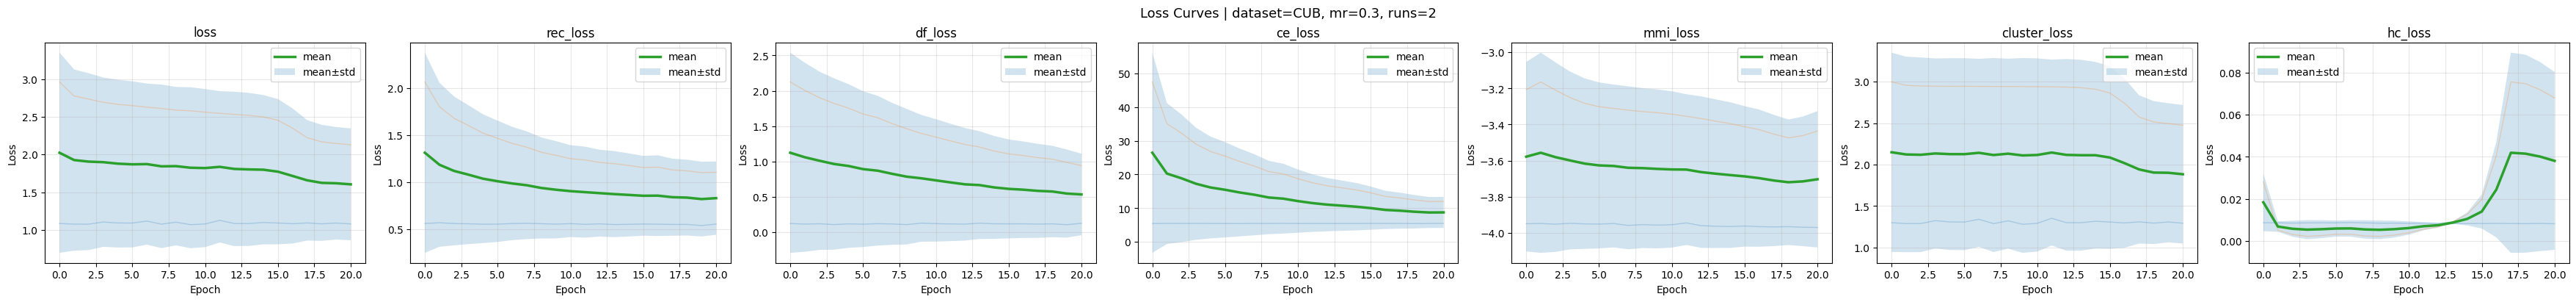

In [34]:
plot_group(
    loss_metrics,
    f'Loss Curves | dataset={dataset_name}, mr={TARGET_MISSING_RATE}, runs={len(csv_files)}',
    'Loss',
)

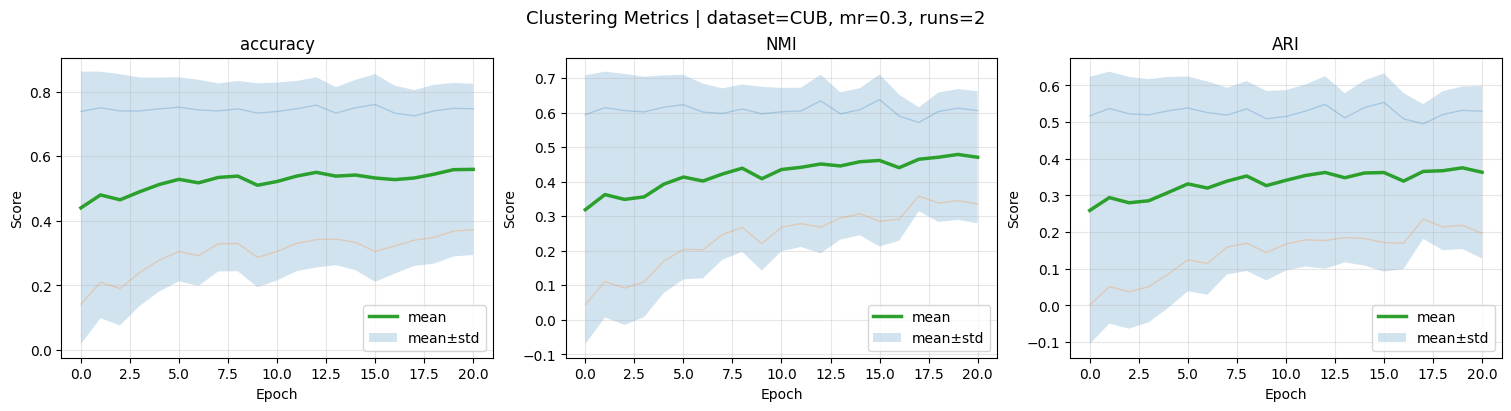

In [55]:
plot_group(
    cluster_metrics,
    f'Clustering Metrics | dataset={dataset_name}, mr={TARGET_MISSING_RATE}, runs={len(csv_files)}',
    'Score',
)

In [54]:
# Optional: show final-epoch summary per run
final_rows = all_df.sort_values('epoch').groupby('run_file', as_index=False).tail(1)
display_cols = ['run_file', 'epoch', 'accuracy', 'NMI', 'ARI', 'loss']
print('\nFinal epoch summary per run:')
display(final_rows[display_cols].sort_values('run_file'))

# Optional: save merged and aggregated tables for external plotting
# merged_out = os.path.join(METRICS_DIR, f"{dataset_name}_mr{safe_mr}_all_runs_metrics.csv")
# agg_out = os.path.join(METRICS_DIR, f"{dataset_name}_mr{safe_mr}_epoch_mean_std_metrics.csv")
# all_df.to_csv(merged_out, index=False)
# agg.to_csv(agg_out, index=False)
# print('\nSaved merged metrics:', merged_out)
# print('Saved epoch mean/std metrics:', agg_out)


Final epoch summary per run:


,run_file,epoch,accuracy,NMI,ARI,loss
20,CUB_mr0p3_seed1_metrics.csv,20,0.7467,0.6056,0.5293,1.080691
41,CUB_mr0p3_seed2_metrics.csv,20,0.3717,0.3353,0.1967,2.128728
